Text(0.5, 0.95, 'Count of equations with R² (test) > 0.999\nby architecture and difficulty')

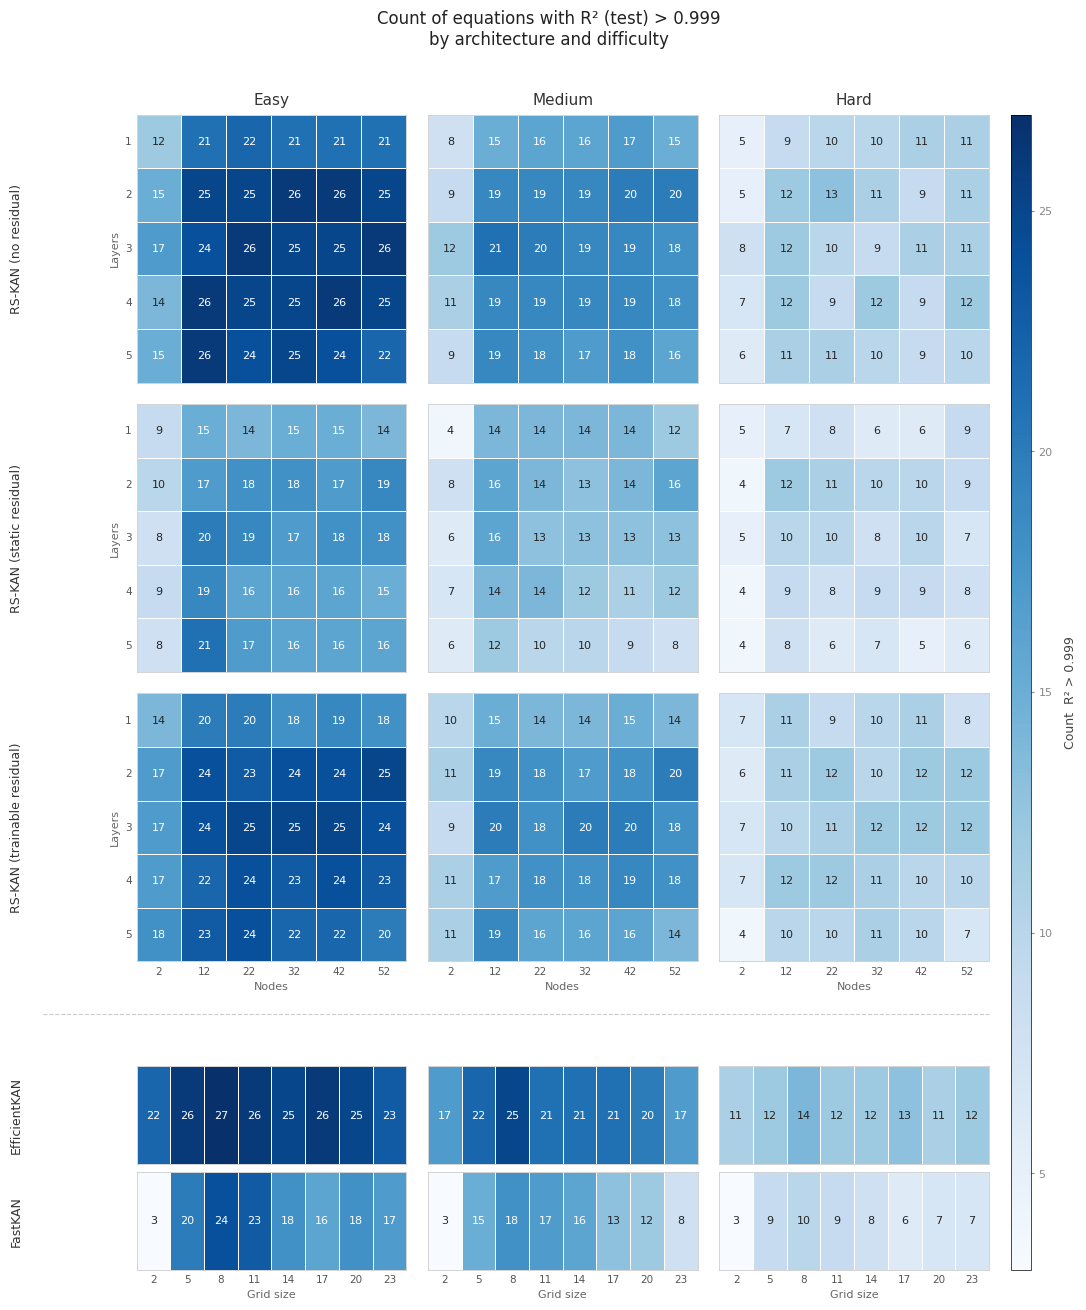

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

THRESHOLD = 0.999
DIFFS     = ["Easy", "Medium", "Hard"]

# ── Heatmap architectures (Nodes × Layers) ───────────────────────────────────
heatmap_files = {
    "RS-KAN\n(no residual)":        "./parameterTests/MLPKAN_nores.csv",
    "RS-KAN\n(static residual)":           "./parameterTests/MLPKAN_res.csv",
    "RS-KAN\n(trainable residual)": "./parameterTests/MLPKAN_restrainable.csv",
}
heatmap_dfs   = {name: pd.read_csv(p) for name, p in heatmap_files.items()}
HEATMAP_ARCHS = list(heatmap_files.keys())
NODES         = sorted(heatmap_dfs[HEATMAP_ARCHS[0]]["Nodes"].unique())
LAYERS        = sorted(heatmap_dfs[HEATMAP_ARCHS[0]]["Layers"].unique())

def make_pivot(df, difficulty):
    sub = df[df["Level"] == difficulty].copy()
    sub["hit"] = (sub["R2 Score (Test)"] > THRESHOLD).astype(int)
    return (
        sub.groupby(["Layers", "Nodes"])["hit"]
        .sum().unstack("Nodes")
        .reindex(index=LAYERS, columns=NODES)
    )

pivots = {a: {d: make_pivot(heatmap_dfs[a], d) for d in DIFFS} for a in HEATMAP_ARCHS}

# ── Strip architectures (Grid Size → 1-row heatmap) ──────────────────────────
strip_files = {
    "EfficientKAN": "./parameterTests/EfficientKAN22.csv",
    "FastKAN":      "./parameterTests/FastKAN2.csv",
}
strip_dfs   = {name: pd.read_csv(p) for name, p in strip_files.items()}
STRIP_ARCHS = list(strip_files.keys())
GRID_SIZES  = sorted(strip_dfs[STRIP_ARCHS[0]]["Grid Size"].unique())

def make_strip(df, difficulty):
    sub = df[df["Level"] == difficulty].copy()
    sub["hit"] = (sub["R2 Score (Test)"] > THRESHOLD).astype(int)
    series = sub.groupby("Grid Size")["hit"].sum().reindex(GRID_SIZES, fill_value=0)
    return pd.DataFrame([series.values], columns=GRID_SIZES, index=[""])

strips = {a: {d: make_strip(strip_dfs[a], d) for d in DIFFS} for a in STRIP_ARCHS}

# ── Shared colour range ───────────────────────────────────────────────────────
all_vals = np.concatenate([
    p.values.ravel() for ad in pivots.values() for p in ad.values()
] + [
    s.values.ravel() for ad in strips.values() for s in ad.values()
])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

# ── Layout ────────────────────────────────────────────────────────────────────
NCOLS         = len(DIFFS)
N_HEAT        = len(HEATMAP_ARCHS)
N_STRP        = len(STRIP_ARCHS)
NROWS         = N_HEAT + N_STRP
STRIP_H_RATIO = 1.8

FIG_W, FIG_H = 11, 15
fig = plt.figure(figsize=(FIG_W, FIG_H))

# Two-section outer GridSpec: larger gap between sections to clear the Nodes axis
outer_gs = gridspec.GridSpec(
    2, 1, figure=fig,
    hspace=0.20,
    height_ratios=[N_HEAT * len(LAYERS), N_STRP * STRIP_H_RATIO],
)
heat_gs = gridspec.GridSpecFromSubplotSpec(
    N_HEAT, NCOLS, subplot_spec=outer_gs[0],
    hspace=0.08, wspace=0.08,
    height_ratios=[len(LAYERS)] * N_HEAT,
)
strp_gs = gridspec.GridSpecFromSubplotSpec(
    N_STRP, NCOLS, subplot_spec=outer_gs[1],
    hspace=0.08, wspace=0.08,
    height_ratios=[STRIP_H_RATIO] * N_STRP,
)

cmap = sns.color_palette("Blues", as_cmap=True)
axes = np.empty((NROWS, NCOLS), dtype=object)

# ── Draw 2-D heatmap rows (MLPKAN) ───────────────────────────────────────────
for ri, arch in enumerate(HEATMAP_ARCHS):
    for ci, diff in enumerate(DIFFS):
        ax = fig.add_subplot(heat_gs[ri, ci])
        axes[ri, ci] = ax

        sns.heatmap(
            pivots[arch][diff], ax=ax,
            cmap=cmap, vmin=vmin, vmax=vmax,
            annot=True, fmt="d", annot_kws={"size": 8},
            linewidths=0.4, linecolor="white",
            cbar=False, xticklabels=True, yticklabels=True,
        )

        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_linewidth(0.6); sp.set_edgecolor("#cccccc")

        if ri == 0:
            ax.set_title(diff, fontsize=11, fontweight="medium", pad=7, color="#333333")

        if ri == N_HEAT - 1:
            ax.set_xlabel("Nodes", fontsize=8, labelpad=4, color="#666666")
            ax.set_xticklabels([str(n) for n in NODES], fontsize=7.5, rotation=0, color="#555555")
        else:
            ax.set_xlabel(""); ax.set_xticklabels([]); ax.tick_params(bottom=False)

        if ci == 0:
            ax.set_ylabel("Layers", fontsize=8, labelpad=4, color="#666666")
            ax.set_yticklabels([str(l) for l in LAYERS], fontsize=7.5, rotation=0, color="#555555")
        else:
            ax.set_ylabel(""); ax.set_yticklabels([]); ax.tick_params(left=False)

        ax.tick_params(length=0)

# ── Draw strip heatmap rows (EfficientKAN, FastKAN) ──────────────────────────
for si, arch in enumerate(STRIP_ARCHS):
    ri = N_HEAT + si
    for ci, diff in enumerate(DIFFS):
        ax = fig.add_subplot(strp_gs[si, ci])
        axes[ri, ci] = ax

        sns.heatmap(
            strips[arch][diff], ax=ax,
            cmap=cmap, vmin=vmin, vmax=vmax,
            annot=True, fmt="d", annot_kws={"size": 8},
            linewidths=0.4, linecolor="white",
            cbar=False, xticklabels=True, yticklabels=False,
        )

        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_linewidth(0.6); sp.set_edgecolor("#cccccc")

        if si == N_STRP - 1:
            ax.set_xlabel("Grid size", fontsize=8, labelpad=4, color="#666666")
            ax.set_xticklabels([str(g) for g in GRID_SIZES], fontsize=7.5, rotation=0, color="#555555")
        else:
            ax.set_xlabel(""); ax.set_xticklabels([]); ax.tick_params(bottom=False)

        ax.set_ylabel("")
        ax.tick_params(length=0)

# ── Architecture row labels (left side) ──────────────────────────────────────
ALL_ARCHS = HEATMAP_ARCHS + STRIP_ARCHS
for ri, arch in enumerate(ALL_ARCHS):
    pos = axes[ri, 0].get_position()
    y_center = (pos.y0 + pos.y1) / 2
    fig.text(
        0.01, y_center, arch.replace("\n", " "),
        va="center", ha="left", rotation=90,
        fontsize=9, fontweight="medium", color="#333333",
    )

# ── Horizontal divider between sections ──────────────────────────────────────
pos_last_heat  = axes[N_HEAT - 1, 0].get_position()
pos_first_strp = axes[N_HEAT, 0].get_position()
y_div = (pos_last_heat.y0 + pos_first_strp.y1) / 2
fig.add_artist(plt.Line2D(
    [0.04, 0.9], [y_div, y_div],
    transform=fig.transFigure,
    color="#cccccc", linewidth=0.8, linestyle="--",
))

# ── Shared colorbar (right edge) ─────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
p_top = axes[0, NCOLS - 1].get_position()
p_bot = axes[NROWS - 1, NCOLS - 1].get_position()
cbar_ax = fig.add_axes([0.92, p_bot.y0, 0.018, p_top.y1 - p_bot.y0])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(f"Count  R² > {THRESHOLD}", fontsize=9, color="#444444", labelpad=8)
cbar.ax.tick_params(labelsize=8, colors="#888888", length=2)
cbar.outline.set_linewidth(0.5)

# ── Overall title ─────────────────────────────────────────────────────────────
fig.suptitle(
    f"Count of equations with R² (test) > {THRESHOLD}\nby architecture and difficulty",
    fontsize=12, fontweight="medium", color="#222222", y=0.95,
)

# plt.savefig("./parameterTests/acc.pdf", bbox_inches="tight", facecolor="white")